# Phase 1: Clinical Text Classification - Baseline Models
**Dataset:** Medical Transcriptions (MTSamples)  
**Task:** Classify medical transcription text into medical specialties  
**Proposal 5 Preparation:** Building baseline before BERT & numeric mapping

### Roadmap:
1. Phase 1 - EDA + TF-IDF Baselines (this notebook)
2. Phase 2 - BERT / ClinicalBERT Fine-tuning
3. Phase 3 - Numeric Mapping + Advanced Techniques
4. Phase 4 - XAI (LIME, SHAP) + Write-up

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mstarefin/medicaltranscriptions/mtsamples.csv")

print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset Shape: (4999, 6)
Columns: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


## 3. Exploratory Data Analysis (EDA)
### 3.1 Basic Info

In [3]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print("Total samples:", len(df))
print("Number of medical specialties:", df["medical_specialty"].nunique())
print()
print("Missing values:")
print(df.isnull().sum())

DATASET OVERVIEW
Total samples: 4999
Number of medical specialties: 40

Missing values:
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


### 3.2 Class Distribution

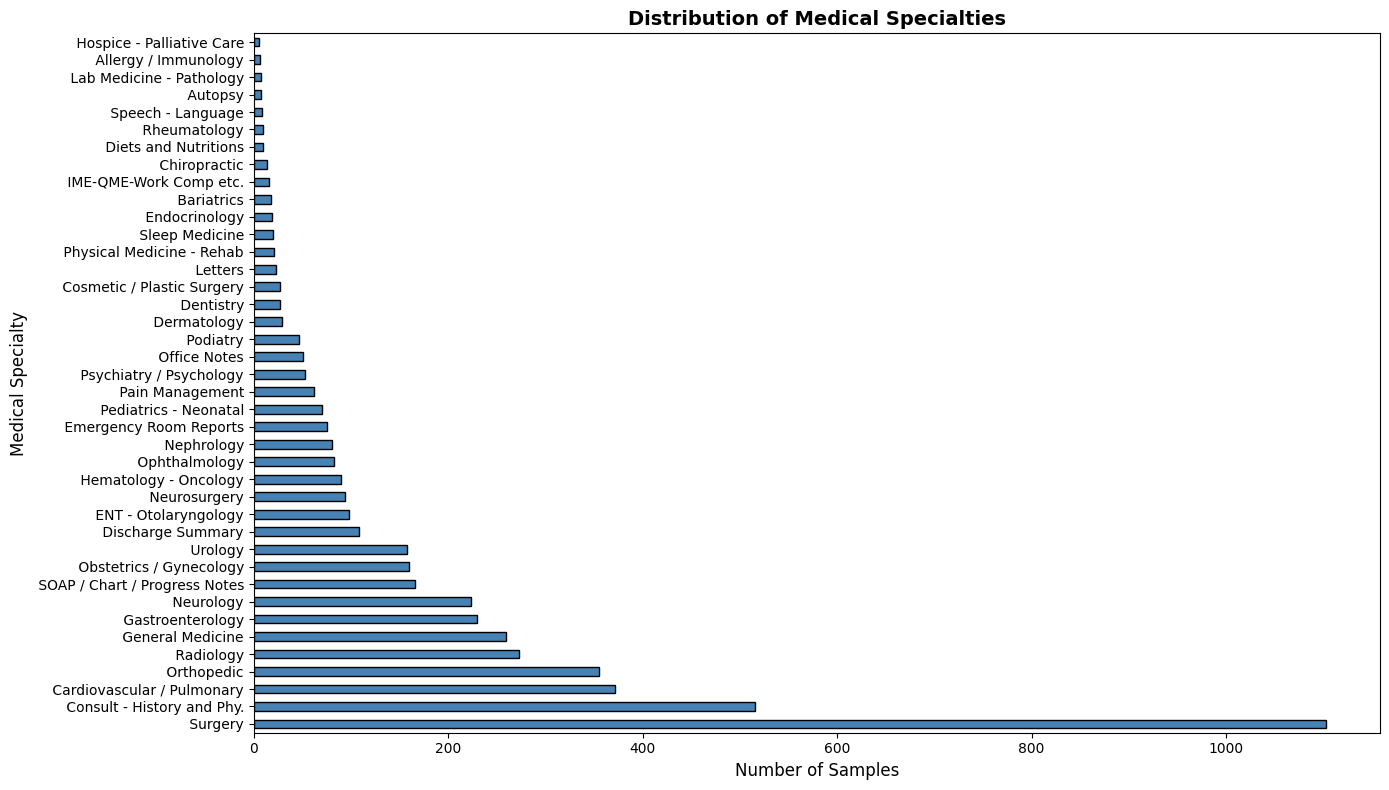

Most common:  Surgery - 1103 samples
Least common:  Hospice - Palliative Care - 6 samples


In [4]:
specialty_counts = df["medical_specialty"].value_counts()

plt.figure(figsize=(14, 8))
specialty_counts.plot(kind="barh", color="steelblue", edgecolor="black")
plt.xlabel("Number of Samples", fontsize=12)
plt.ylabel("Medical Specialty", fontsize=12)
plt.title("Distribution of Medical Specialties", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Most common:", specialty_counts.index[0], "-", specialty_counts.iloc[0], "samples")
print("Least common:", specialty_counts.index[-1], "-", specialty_counts.iloc[-1], "samples")

### 3.3 Text Length Analysis

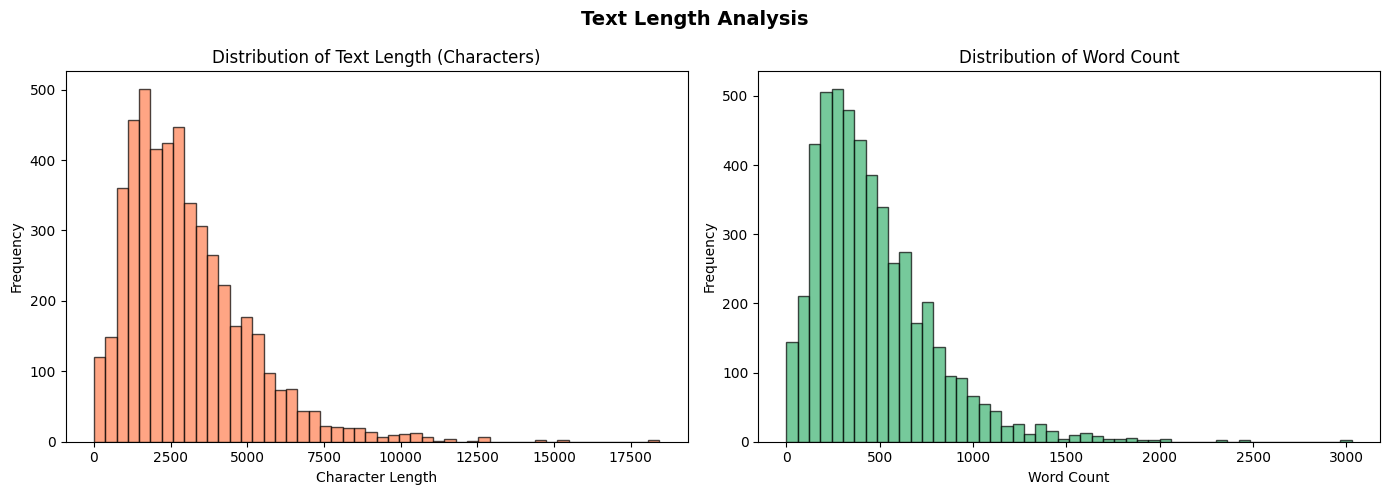

Average word count: 462
Median word count: 397
Max word count: 3029


In [5]:
df["text_length"] = df["transcription"].fillna("").apply(len)
df["word_count"] = df["transcription"].fillna("").apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["text_length"], bins=50, color="coral", edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Character Length")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Text Length (Characters)")

axes[1].hist(df["word_count"], bins=50, color="mediumseagreen", edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Word Count")

plt.suptitle("Text Length Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Average word count:", round(df["word_count"].mean()))
print("Median word count:", round(df["word_count"].median()))
print("Max word count:", df["word_count"].max())

### 3.4 Average Text Length per Specialty

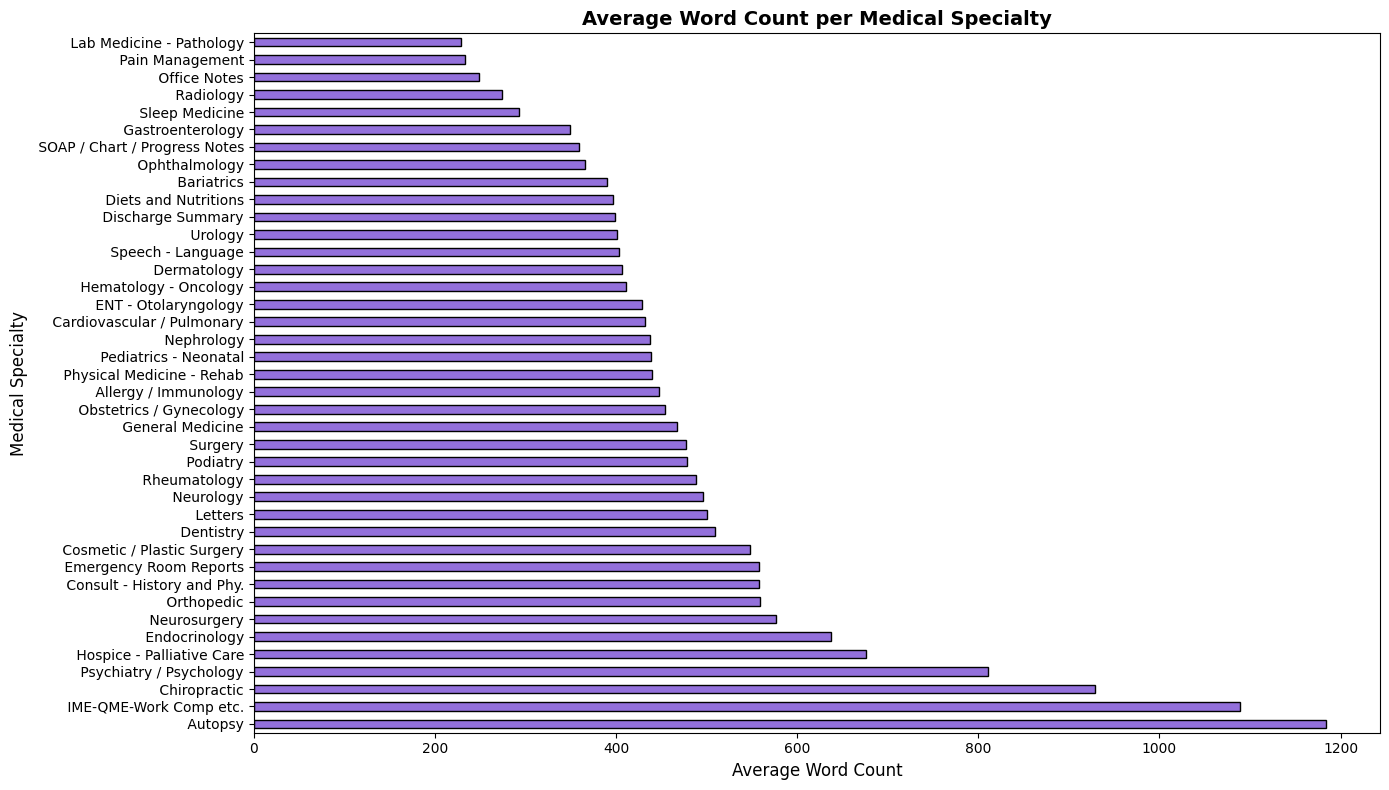

In [6]:
avg_words = df.groupby("medical_specialty")["word_count"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
avg_words.plot(kind="barh", color="mediumpurple", edgecolor="black")
plt.xlabel("Average Word Count", fontsize=12)
plt.ylabel("Medical Specialty", fontsize=12)
plt.title("Average Word Count per Medical Specialty", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Data Preprocessing
### 4.1 Filter Classes & Handle Missing Values

In [7]:
print("Before dropping nulls:", len(df), "samples")
df = df.dropna(subset=["transcription"])
print("After dropping nulls:", len(df), "samples")

MIN_SAMPLES = 50
valid_specialties = specialty_counts[specialty_counts >= MIN_SAMPLES].index.tolist()
df_filtered = df[df["medical_specialty"].isin(valid_specialties)].copy()

print()
print("Specialties with >=", MIN_SAMPLES, "samples:", len(valid_specialties))
print("Filtered dataset size:", len(df_filtered), "samples")
print()
print("Selected specialties:")
for s in valid_specialties:
    print("  -", s + ":", specialty_counts[s], "samples")

Before dropping nulls: 4999 samples
After dropping nulls: 4966 samples

Specialties with >= 50 samples: 22
Filtered dataset size: 4647 samples

Selected specialties:
  -  Surgery: 1103 samples
  -  Consult - History and Phy.: 516 samples
  -  Cardiovascular / Pulmonary: 372 samples
  -  Orthopedic: 355 samples
  -  Radiology: 273 samples
  -  General Medicine: 259 samples
  -  Gastroenterology: 230 samples
  -  Neurology: 223 samples
  -  SOAP / Chart / Progress Notes: 166 samples
  -  Obstetrics / Gynecology: 160 samples
  -  Urology: 158 samples
  -  Discharge Summary: 108 samples
  -  ENT - Otolaryngology: 98 samples
  -  Neurosurgery: 94 samples
  -  Hematology - Oncology: 90 samples
  -  Ophthalmology: 83 samples
  -  Nephrology: 81 samples
  -  Emergency Room Reports: 75 samples
  -  Pediatrics - Neonatal: 70 samples
  -  Pain Management: 62 samples
  -  Psychiatry / Psychology: 53 samples
  -  Office Notes: 51 samples


### 4.2 Text Cleaning

In [8]:
def clean_text(text):
    """Clean medical transcription text"""
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_filtered["clean_text"] = df_filtered["transcription"].apply(clean_text)

print("EXAMPLE - Original vs Cleaned Text")
print("=" * 60)
original = df_filtered["transcription"].iloc[0][:300]
cleaned = df_filtered["clean_text"].iloc[0][:300]
print()
print("Original (first 300 chars):")
print(original)
print()
print("Cleaned (first 300 chars):")
print(cleaned)

EXAMPLE - Original vs Cleaned Text

Original (first 300 chars):
2-D M-MODE: , ,1.  Left atrial enlargement with left atrial diameter of 4.7 cm.,2.  Normal size right and left ventricle.,3.  Normal LV systolic function with left ventricular ejection fraction of 51%.,4.  Normal LV diastolic function.,5.  No pericardial effusion.,6.  Normal morphology of aortic val

Cleaned (first 300 chars):
d m mode left atrial enlargement with left atrial diameter of cm normal size right and left ventricle normal lv systolic function with left ventricular ejection fraction of normal lv diastolic function no pericardial effusion normal morphology of aortic valve mitral valve tricuspid valve and pulmona


## 5. Feature Extraction & Model Training
### 5.1 TF-IDF Vectorization

In [9]:
X = df_filtered["clean_text"]
y = df_filtered["medical_specialty"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training set:", len(X_train), "samples")
print("Test set:", len(X_test), "samples")

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape:", X_train_tfidf.shape)

Training set: 3717 samples
Test set: 930 samples
TF-IDF matrix shape: (3717, 10000)


### 5.2 Train Baseline Models

In [10]:
print("TRAINING BASELINE MODELS")
print("=" * 60)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    print()
    print("Training " + name + "...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        "model": model,
        "accuracy": acc,
        "predictions": y_pred
    }
    print("  {} Accuracy: {:.4f} ({:.2f}%)".format(name, acc, acc * 100))

TRAINING BASELINE MODELS

Training Logistic Regression...
  Logistic Regression Accuracy: 0.2763 (27.63%)

Training Linear SVM...
  Linear SVM Accuracy: 0.1344 (13.44%)

Training Random Forest...
  Random Forest Accuracy: 0.1269 (12.69%)


## 6. Evaluation & Analysis
### 6.1 Model Comparison

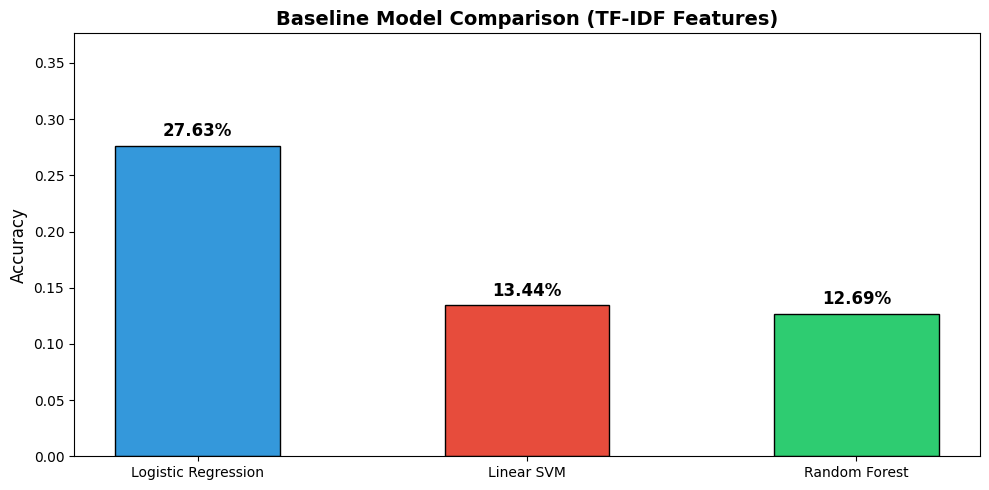

In [11]:
model_names = list(results.keys())
accuracies = [results[m]["accuracy"] for m in model_names]

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, accuracies, color=["#3498db", "#e74c3c", "#2ecc71"],
               edgecolor="black", width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             "{:.2f}%".format(acc * 100), ha="center", va="bottom", fontweight="bold", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Baseline Model Comparison (TF-IDF Features)", fontsize=14, fontweight="bold")
plt.ylim(0, max(accuracies) + 0.1)
plt.tight_layout()
plt.show()

### 6.2 Best Model - Detailed Classification Report

In [12]:
best_model_name = max(results, key=lambda x: results[x]["accuracy"])
best_preds = results[best_model_name]["predictions"]

print("Best Model:", best_model_name)
print("Accuracy: {:.2f}%".format(results[best_model_name]["accuracy"] * 100))
print()
print("Classification Report (" + best_model_name + "):")
print(classification_report(
    y_test, best_preds,
    target_names=le.classes_,
    zero_division=0
))

Best Model: Logistic Regression
Accuracy: 27.63%

Classification Report (Logistic Regression):
                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.27      0.27      0.27        74
    Consult - History and Phy.       0.26      0.50      0.34       103
             Discharge Summary       0.35      0.36      0.36        22
          ENT - Otolaryngology       0.25      0.05      0.09        19
        Emergency Room Reports       0.00      0.00      0.00        15
              Gastroenterology       0.09      0.04      0.06        45
              General Medicine       0.07      0.06      0.06        52
         Hematology - Oncology       0.00      0.00      0.00        18
                    Nephrology       0.00      0.00      0.00        16
                     Neurology       0.22      0.18      0.20        45
                  Neurosurgery       0.00      0.00      0.00        19
       Obstetrics / Gynecology       0.2

### 6.3 Confusion Matrix

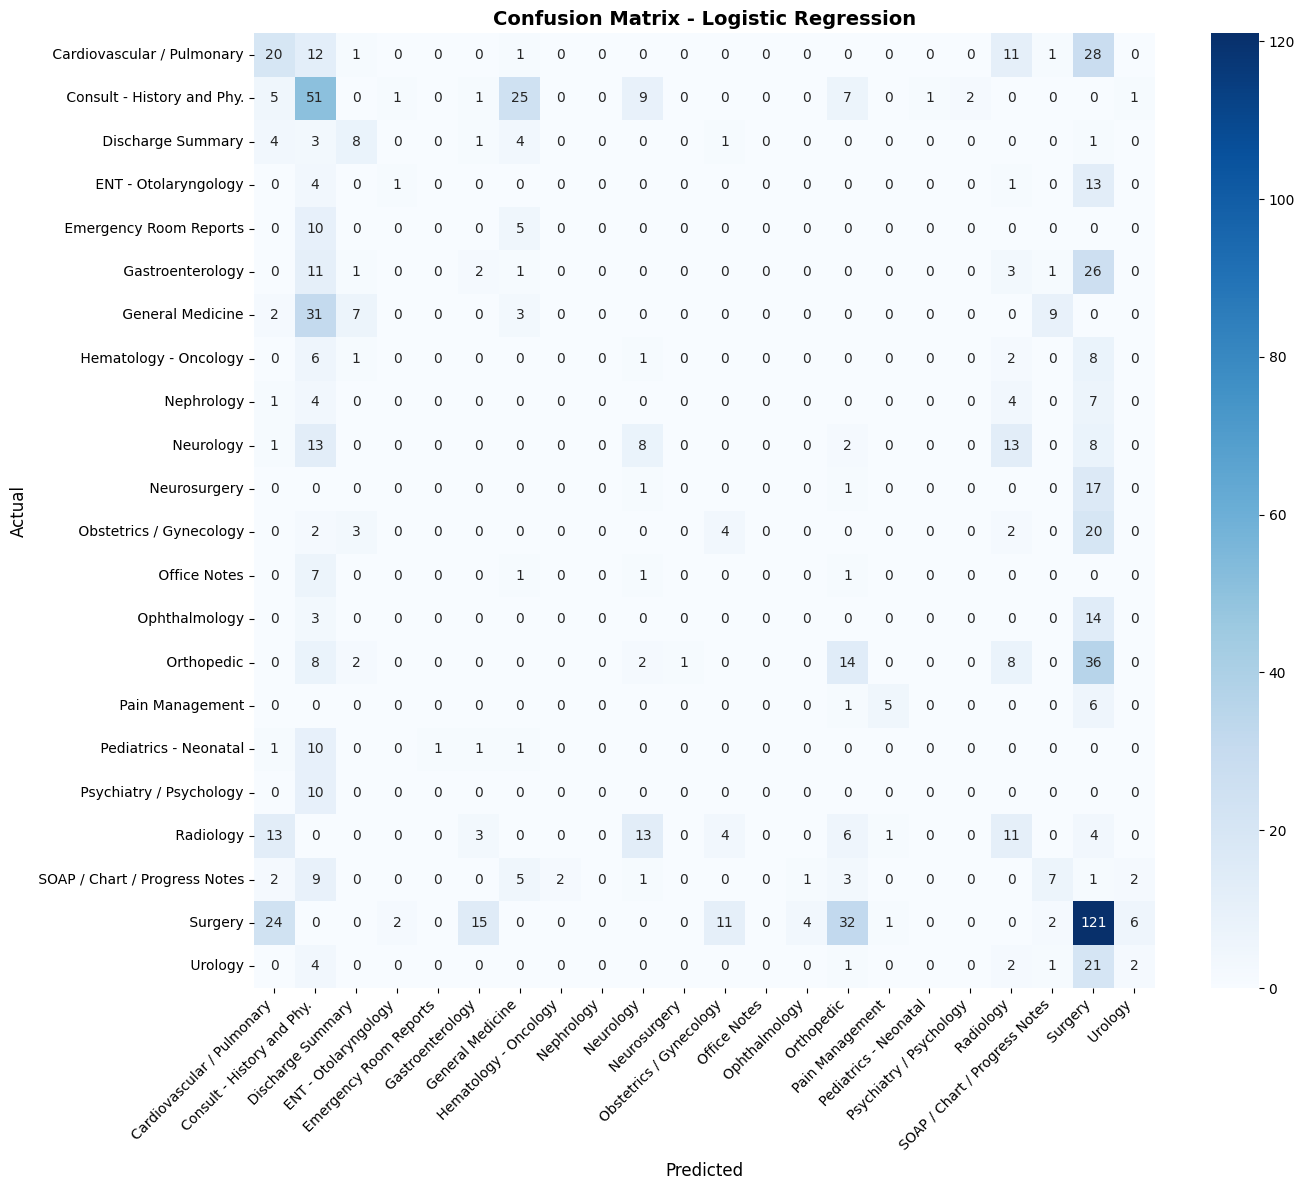

In [13]:
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix - " + best_model_name, fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.4 Top TF-IDF Features per Specialty

In [14]:
print("TOP 10 TF-IDF FEATURES PER SPECIALTY")
print("=" * 60)

lr_model = results["Logistic Regression"]["model"]
feature_names = tfidf.get_feature_names_out()

for i, specialty in enumerate(le.classes_[:5]):
    top_indices = lr_model.coef_[i].argsort()[-10:][::-1]
    top_features = [feature_names[j] for j in top_indices]
    print()
    print(specialty + ":")
    print("  " + ", ".join(top_features))

TOP 10 TF-IDF FEATURES PER SPECIALTY

 Cardiovascular / Pulmonary:
  chest, artery, lobe, coronary, atrial, heart, pulmonary, predicted, lung, upper lobe

 Consult - History and Phy.:
  history, weight, food, medical, consultation, past, social, denies, discussed, allergies

 Discharge Summary:
  discharge, admission, hospital course, hospital, course, home, mg, daily, discharged, patient

 ENT - Otolaryngology:
  nasal, ear, tonsil, cartilage, tonsillitis, adenoid, tonsillar, septum, palate, tube

 Emergency Room Reports:
  emergency, patient, denies, emergency department, pain, history, emergency room, past, states, normal


## 7. Numeric Content Analysis (Prep for Proposal 5)
This section analyzes numeric values in clinical text, setting up for the **numeric mapping technique** in Phase 3.

In [15]:
print("NUMERIC CONTENT ANALYSIS")
print("=" * 60)
print("(Preparation for numeric mapping technique in Proposal 5)")

def count_numbers(text):
    numbers = re.findall(r"\d+\.?\d*", text)
    return len(numbers)

df_filtered["num_count"] = df_filtered["transcription"].apply(count_numbers)

print()
print("Average numbers per transcription:", round(df_filtered["num_count"].mean(), 1))
print("Max numbers in a single transcription:", df_filtered["num_count"].max())

print()
print("Examples of numeric values in clinical text:")
sample_text = df_filtered["transcription"].iloc[0]
numbers_with_context = re.findall(r".{0,30}\d+\.?\d*.{0,30}", sample_text)
for i, example in enumerate(numbers_with_context[:5]):
    print("  {}. ...{}...".format(i + 1, example.strip()))

NUMERIC CONTENT ANALYSIS
(Preparation for numeric mapping technique in Proposal 5)

Average numbers per transcription: 20.9
Max numbers in a single transcription: 136

Examples of numeric values in clinical text:
  1. ...2-D M-MODE: , ,1.  Left atrial enlargement with...
  2. ...left atrial diameter of 4.7 cm.,2.  Normal size right and...
  3. ...left ventricle.,3.  Normal LV systolic function...
  4. ...tricular ejection fraction of 51%.,4.  Normal LV diastolic fun...
  5. ...ction.,5.  No pericardial effusion.,6....


## Summary & Next Steps

In [16]:
print("=" * 60)
print("PHASE 1 COMPLETE!")
print("=" * 60)
print()
print("Summary:")
print("- Dataset: MTSamples Medical Transcriptions")
print("- Task: Multi-class text classification (medical specialty prediction)")
print("- Best Baseline Model:", best_model_name, "({:.2f}% accuracy)".format(results[best_model_name]["accuracy"] * 100))
print()
print("Next Steps (Phase 2):")
print("- Fine-tune BERT/ClinicalBERT for classification")
print("- Compare with TF-IDF baselines")
print("- Implement numeric mapping technique")

PHASE 1 COMPLETE!

Summary:
- Dataset: MTSamples Medical Transcriptions
- Task: Multi-class text classification (medical specialty prediction)
- Best Baseline Model: Logistic Regression (27.63% accuracy)

Next Steps (Phase 2):
- Fine-tune BERT/ClinicalBERT for classification
- Compare with TF-IDF baselines
- Implement numeric mapping technique


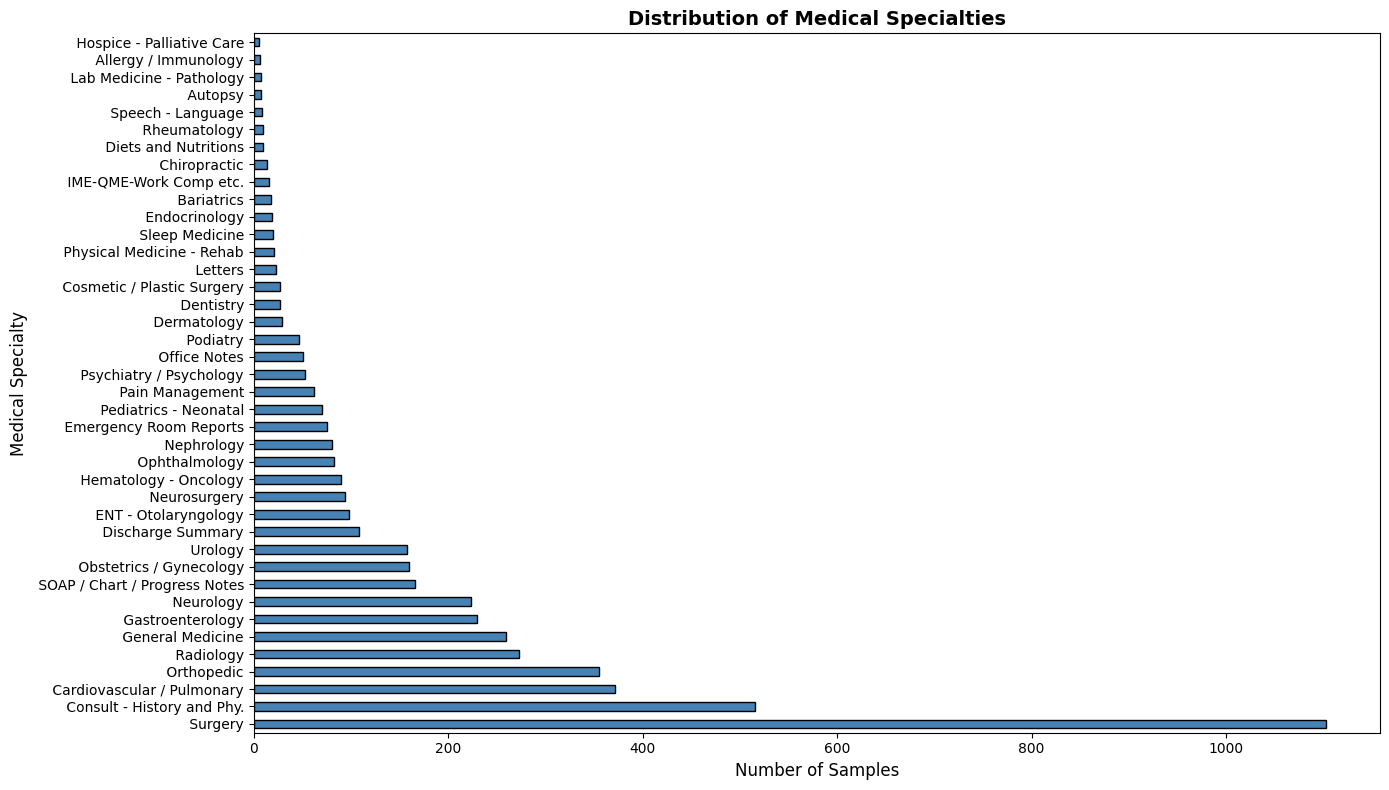

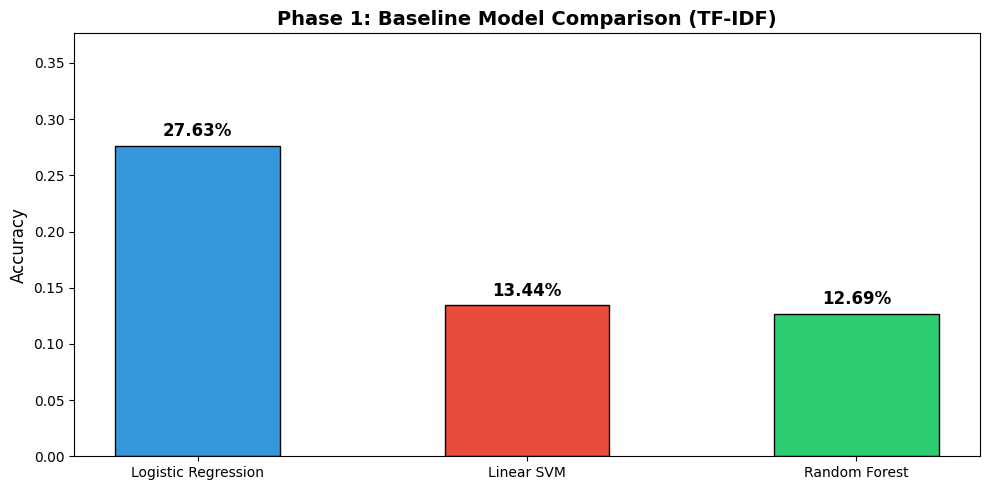

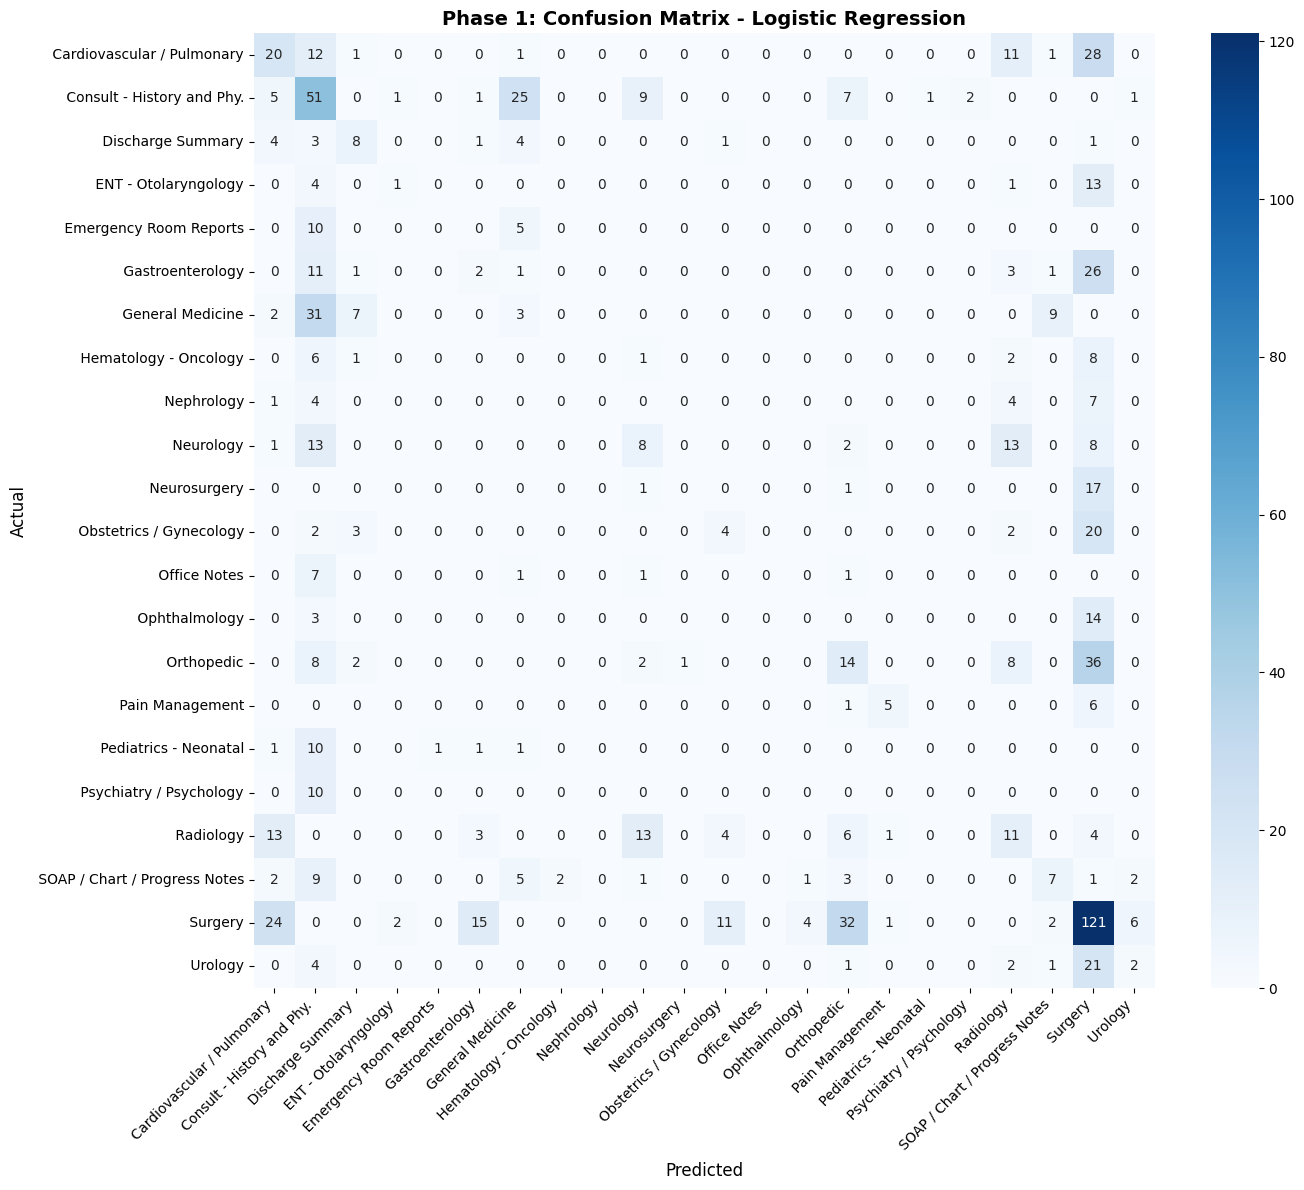

Phase 1 figures saved!


In [17]:
# === SAVE ALL FIGURES ===
# 1. Class Distribution
plt.figure(figsize=(14, 8))
specialty_counts.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Medical Specialty', fontsize=12)
plt.title('Distribution of Medical Specialties', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Model Comparison
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, accuracies, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             '{:.2f}%'.format(acc * 100), ha='center', va='bottom', fontweight='bold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Phase 1: Baseline Model Comparison (TF-IDF)', fontsize=14, fontweight='bold')
plt.ylim(0, max(accuracies) + 0.1)
plt.tight_layout()
plt.savefig('phase1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Confusion Matrix
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Phase 1: Confusion Matrix - ' + best_model_name, fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('phase1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Phase 1 figures saved!")